# Spectrophotometer pipeline — user single-file Colab

This notebook analyzes spectrophotometer spectra of scintillator samples measured before and after irradiation.

The notebook is intentionally self-contained: users should edit only the configuration/GUI section at the beginning. No external JSON configuration is required. The example files included with this project are **test-format files only**. They are used to demonstrate the expected file structure and notebook behavior; they are not treated as real measurement results.

Main physical rule: **direct transmittance and absorbance are calculated only for measurements taken at the same diode current, in the same geometry, and relative to the matching air/empty-holder blank.**

The spectrometer export is assumed to be already dark-corrected. Dark files are **not subtracted**. They are displayed only as QC spectra to check light leakage, stray light, or acquisition problems.

New in v5:

- default Google Drive data directory points to the shared Dose3D-Future spectrophotometry folder,
- direct and scattering dark QC files are included as separate GUI fields by default,
- file naming convention is clarified: `whiteLED` means the white diode/source; for 472 nm measurements use `LED472nm`,
- dark QC remains display-only; it does not modify transmittance, absorbance or integrals.


## 1. Imports and environment setup

Run this cell first. In Google Colab, widgets create a simple graphical configuration panel. If widgets do not work, edit the manual fallback dictionaries in the next cell.

In [1]:
import os
import math
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.signal import savgol_filter
except Exception:
    savgol_filter = None

try:
    import ipywidgets as widgets
    from IPython.display import display, HTML
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

## 2. User configuration GUI

Edit this section for each measurement campaign.

Every important file is selected separately. This is deliberate: automatic folder scanning is convenient, but risky during user measurement campaigns because a wrong file can silently enter the analysis.

The default Google Drive data directory after mounting Drive in Colab is:

```text
/content/drive/Shareddrives/TN-Dose3D-Future-DAQ/Data/Spectrophotometry/Test_Measurements
```

If this folder is not available, the notebook falls back to the bundled `example_data/raw` folder. This allows the notebook to be tested outside Colab.

Use the fields as follows:

- `Data/root dir` — folder with spectrophotometer TXT files. In Colab this should usually be the shared-drive path above.
- `Output dir` — folder where figures, CSV files and reports will be saved.
- `Direct blank` — air / empty holder in the direct transmission path. This is the reference for transmittance.
- `Direct dark QC` — optional dark spectrum for direct geometry. Display only; not subtracted.
- `Direct quartz` — optional fused silica / quartz control sample. Used to verify setup stability.
- `Direct samples` — scintillator samples measured in direct transmission. Add one row per dose/sample.
- `Scattering blank` — optional empty-holder/background file in 90° geometry.
- `Scattering dark QC` — optional dark spectrum in 90° geometry. Display only; not subtracted.
- `Scattering quartz` — optional quartz/fused-silica scattering control.
- `Scattering samples` — scintillator scattering spectra. Add one row per dose/sample.

Recommended file-name convention:

```text
role__source__geometry__condition__sample-or-run.txt
```

Examples:

```text
blank__whiteLED__direct-0deg__40uA__empty-holder__run01.txt
sample__whiteLED__direct-0deg__40uA__scint-A__dose-0Gy__run01.txt
sample__LED472nm__direct-0deg__40uA__scint-A__dose-0Gy__run01.txt
dark__whiteLED__direct-0deg__LED-off__run01.txt
dark__whiteLED__scatter-90deg__LED-off__run01.txt
quartz__whiteLED__direct-0deg__40uA__fused-silica__run01.txt
quartz__whiteLED__scatter-90deg__40mA__fused-silica__run01.txt
```

Here `whiteLED` means the color/source type of the diode. For monochromatic 472 nm measurements, use `LED472nm` in the same position.

Noise controls:

- `Baseline ranges` define wavelength intervals where no useful signal is expected. They are used to estimate residual offset and noise.
- `Blank min frac` defines the minimum accepted blank level relative to the blank peak. Below this, `sample/blank` is not calculated.
- `Signal floor frac` defines the minimum accepted signal level relative to each spectrum peak. Values below this floor are set to zero for gated spectra and integrals.
- `Noise sigma x` defines an additional robust-noise threshold. The effective floor is the larger of the fractional threshold and `Noise sigma x × baseline_noise`.


In [2]:
# ---- Default paths ----
# In Colab, mount Google Drive first, then use the shared-drive path below.
# If the shared-drive folder is not visible in the current environment, the notebook falls back to bundled test-format data.

GOOGLE_DRIVE_DATA_DIR_DEFAULT = "/content/drive/Shareddrives/TN-Dose3D-Future-DAQ/Data/Spectrophotometry/Test_Measurements"
LOCAL_PROJECT_ROOT_DEFAULT = "../"
LOCAL_EXAMPLE_RAW_DIR_DEFAULT = f"{LOCAL_PROJECT_ROOT_DEFAULT}/example_data/raw"

RAW_DIR_DEFAULT = GOOGLE_DRIVE_DATA_DIR_DEFAULT if Path(GOOGLE_DRIVE_DATA_DIR_DEFAULT).exists() else LOCAL_EXAMPLE_RAW_DIR_DEFAULT
OUTPUT_DIR_DEFAULT = f"{RAW_DIR_DEFAULT}/analysis_outputs"

if WIDGETS_AVAILABLE:
    header_style = "font-weight:700; font-size:16px; margin-top:12px;"

    project_root_w = widgets.Text(value=RAW_DIR_DEFAULT, description="Data/root dir:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"})
    output_dir_w = widgets.Text(value=OUTPUT_DIR_DEFAULT, description="Output dir:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"})

    direct_blank_file_w = widgets.Text(value=f"{RAW_DIR_DEFAULT}/blank__whiteLED__direct-0deg__40uA__empty-holder__run01.txt", description="Direct blank:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"})
    direct_dark_qc_file_w = widgets.Text(value=f"{RAW_DIR_DEFAULT}/dark__whiteLED__direct-0deg__LED-off__run01.txt", description="Direct dark QC:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"}, placeholder="Display only; not subtracted.")
    direct_quartz_file_w = widgets.Text(value="", description="Direct quartz:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"}, placeholder="Optional quartz/fused silica control sample.")

    direct_samples_w = widgets.Textarea(
        value=(
            "dataset_id,sample_id,dose_label,current_value,current_unit,file_path\n"
            f"sample_whiteLED_direct_40uA_test,scintillator_test,test_format,40,uA,{RAW_DIR_DEFAULT}/sample__whiteLED__direct-0deg__40uA__scintillator-test__run01.txt\n"
            f"sample_whiteLED_direct_200uA_shape_only,scintillator_test,test_format,200,uA,{RAW_DIR_DEFAULT}/sample__whiteLED__direct-0deg__200uA__scintillator-test__run01.txt"
        ),
        description="Direct samples:", layout=widgets.Layout(width="95%", height="130px"), style={"description_width":"170px"}
    )

    scattering_blank_file_w = widgets.Text(value="", description="Scattering blank:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"}, placeholder="Optional empty holder/background in 90° geometry.")
    scattering_dark_qc_file_w = widgets.Text(value=f"{RAW_DIR_DEFAULT}/dark__whiteLED__scatter-90deg__LED-off__run01.txt", description="Scatt. dark QC:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"}, placeholder="Display only; not subtracted.")
    scattering_quartz_file_w = widgets.Text(value="", description="Scatt. quartz:", layout=widgets.Layout(width="95%"), style={"description_width":"170px"}, placeholder="Optional quartz/fused silica scattering control.")
    scattering_samples_w = widgets.Textarea(
        value=(
            "dataset_id,sample_id,dose_label,current_value,current_unit,file_path\n"
            f"sample_whiteLED_scatter90_40mA_test,scintillator_test,test_format,40,mA,{RAW_DIR_DEFAULT}/sample__whiteLED__scatter-90deg__40mA__scintillator-test__run01.txt"
        ),
        description="Scatt. samples:", layout=widgets.Layout(width="95%", height="110px"), style={"description_width":"170px"}
    )

    direct_current_value_w = widgets.FloatText(value=40, description="Blank current:", style={"description_width":"170px"})
    direct_current_unit_w = widgets.Dropdown(options=["uA", "mA", "A"], value="uA", description="Blank unit:", style={"description_width":"170px"})
    scattering_current_value_w = widgets.FloatText(value=40, description="Scatt. current:", style={"description_width":"170px"})
    scattering_current_unit_w = widgets.Dropdown(options=["uA", "mA", "A"], value="mA", description="Scatt. unit:", style={"description_width":"170px"})

    path_length_mm_w = widgets.FloatText(value=10.0, description="Path length [mm]:", style={"description_width":"170px"})
    analysis_window_w = widgets.Text(value="400,750", description="Analysis window:", style={"description_width":"170px"})
    baseline_ranges_w = widgets.Text(value="190,350;850,1020", description="Baseline ranges:", style={"description_width":"170px"})
    blank_min_fraction_w = widgets.FloatText(value=0.02, description="Blank min frac:", style={"description_width":"170px"})
    signal_floor_fraction_w = widgets.FloatText(value=0.005, description="Signal floor frac:", style={"description_width":"170px"})
    noise_sigma_multiplier_w = widgets.FloatText(value=5.0, description="Noise sigma x:", style={"description_width":"170px"})
    max_transmittance_w = widgets.FloatText(value=1.20, description="Max valid T:", style={"description_width":"170px"})
    smooth_window_w = widgets.IntText(value=41, description="Smooth window:", style={"description_width":"170px"})

    display(HTML(f"<div style='{header_style}'>Project paths</div>"))
    display(project_root_w, output_dir_w)
    display(HTML(f"<div style='{header_style}'>Direct transmission files</div>"))
    display(direct_blank_file_w, direct_dark_qc_file_w, direct_quartz_file_w, direct_samples_w)
    display(HTML(f"<div style='{header_style}'>Scattering files</div>"))
    display(scattering_blank_file_w, scattering_dark_qc_file_w, scattering_quartz_file_w, scattering_samples_w)
    display(HTML(f"<div style='{header_style}'>Measurement and analysis parameters</div>"))
    display(widgets.HBox([direct_current_value_w, direct_current_unit_w]))
    display(widgets.HBox([scattering_current_value_w, scattering_current_unit_w]))
    display(widgets.HBox([path_length_mm_w, smooth_window_w]))
    display(widgets.HBox([analysis_window_w, baseline_ranges_w]))
    display(widgets.HBox([blank_min_fraction_w, signal_floor_fraction_w, noise_sigma_multiplier_w, max_transmittance_w]))
else:
    print("ipywidgets not available. Edit the manual CONFIG section in the next cell.")


Text(value='..//example_data/raw', description='Data/root dir:', layout=Layout(width='95%'), style=TextStyle(d…

Text(value='..//example_data/raw/analysis_outputs', description='Output dir:', layout=Layout(width='95%'), sty…

Text(value='..//example_data/raw/blank__whiteLED__direct-0deg__40uA__empty-holder__run01.txt', description='Di…

Text(value='..//example_data/raw/dark__whiteLED__direct-0deg__LED-off__run01.txt', description='Direct dark QC…

Text(value='', description='Direct quartz:', layout=Layout(width='95%'), placeholder='Optional quartz/fused si…

Textarea(value='dataset_id,sample_id,dose_label,current_value,current_unit,file_path\nsample_whiteLED_direct_4…

Text(value='', description='Scattering blank:', layout=Layout(width='95%'), placeholder='Optional empty holder…

Text(value='..//example_data/raw/dark__whiteLED__scatter-90deg__LED-off__run01.txt', description='Scatt. dark …

Text(value='', description='Scatt. quartz:', layout=Layout(width='95%'), placeholder='Optional quartz/fused si…

Textarea(value='dataset_id,sample_id,dose_label,current_value,current_unit,file_path\nsample_whiteLED_scatter9…

## 3. Build configuration from the GUI

Run this cell after editing the GUI. It converts widget values into a `CONFIG` dictionary and a `MEASUREMENTS` table.

For direct transmittance, only rows with the same current, same current unit and same geometry as the direct blank are converted into `same_current_transmittance`. Other direct sample rows are kept as `sample_only_shape_diagnostic`.

In [3]:
def _parse_pair(text_value, default=(400.0, 750.0)):
    try:
        a, b = [float(x.strip()) for x in str(text_value).split(",")[:2]]
        return (a, b)
    except Exception:
        return default


def _parse_ranges(text_value):
    ranges = []
    for part in str(text_value).split(";"):
        part = part.strip()
        if not part:
            continue
        try:
            a, b = [float(x.strip()) for x in part.split(",")[:2]]
            ranges.append((a, b))
        except Exception:
            pass
    return ranges or [(900.0, 1000.0)]


def _clean_path(x):
    x = str(x).strip()
    return x if x else None


def _table_from_textarea(text_value, section, role, geometry):
    text_value = str(text_value).strip()
    if not text_value:
        return pd.DataFrame(columns=["dataset_id", "sample_id", "dose_label", "current_value", "current_unit", "file_path", "section", "role", "geometry"])
    df = pd.read_csv(StringIO(text_value))
    required = ["dataset_id", "sample_id", "dose_label", "current_value", "current_unit", "file_path"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {role} table: {missing}")
    df["section"] = section
    df["role"] = role
    df["geometry"] = geometry
    return df


def _single_measurement(dataset_id, sample_id, role, section, geometry, file_path, current_value, current_unit, dose_label="none"):
    if not file_path:
        return None
    return {
        "dataset_id": dataset_id,
        "sample_id": sample_id,
        "dose_label": dose_label,
        "current_value": float(current_value),
        "current_unit": str(current_unit),
        "file_path": file_path,
        "section": section,
        "role": role,
        "geometry": geometry,
    }

if WIDGETS_AVAILABLE:
    CONFIG = {
        "data_root": project_root_w.value.strip(),
        "output_dir": output_dir_w.value.strip(),
        "analysis_window_nm": _parse_pair(analysis_window_w.value, default=(400.0, 750.0)),
        "baseline_ranges_nm": _parse_ranges(baseline_ranges_w.value),
        "blank_min_fraction_of_peak": float(blank_min_fraction_w.value),
        "signal_floor_fraction_of_peak": float(signal_floor_fraction_w.value),
        "noise_sigma_multiplier": float(noise_sigma_multiplier_w.value),
        "clip_negative_after_baseline": True,
        "max_valid_transmittance": float(max_transmittance_w.value),
        "absorbance_floor": 1e-4,
        "smoothing_window_points": int(smooth_window_w.value),
        "smoothing_polyorder": 3,
        "path_length_mm": float(path_length_mm_w.value),
        "spectrometer_already_dark_corrected": True,
        "dark_files_are_qc_only": True,
    }

    rows = []
    for item in [
        _single_measurement("direct_blank", "empty_holder", "blank_reference", "direct", "direct", _clean_path(direct_blank_file_w.value), direct_current_value_w.value, direct_current_unit_w.value),
        _single_measurement("direct_dark_qc", "dark", "dark_qc", "direct", "direct", _clean_path(direct_dark_qc_file_w.value), direct_current_value_w.value, direct_current_unit_w.value),
        _single_measurement("direct_quartz_reference", "quartz", "quartz_reference", "direct", "direct", _clean_path(direct_quartz_file_w.value), direct_current_value_w.value, direct_current_unit_w.value),
        _single_measurement("scattering_blank", "empty_holder", "scattering_blank", "scattering", "90deg", _clean_path(scattering_blank_file_w.value), scattering_current_value_w.value, scattering_current_unit_w.value),
        _single_measurement("scattering_dark_qc", "dark", "scattering_dark_qc", "scattering", "90deg", _clean_path(scattering_dark_qc_file_w.value), scattering_current_value_w.value, scattering_current_unit_w.value),
        _single_measurement("scattering_quartz", "quartz", "scattering_quartz", "scattering", "90deg", _clean_path(scattering_quartz_file_w.value), scattering_current_value_w.value, scattering_current_unit_w.value),
    ]:
        if item is not None:
            rows.append(item)

    direct_samples_df = _table_from_textarea(direct_samples_w.value, "direct", "sample", "direct")
    scattering_samples_df = _table_from_textarea(scattering_samples_w.value, "scattering", "scattering_sample", "90deg")
    MEASUREMENTS = pd.concat([pd.DataFrame(rows), direct_samples_df, scattering_samples_df], ignore_index=True)
else:
    CONFIG = {
        "data_root": RAW_DIR_DEFAULT,
        "output_dir": OUTPUT_DIR_DEFAULT,
        "analysis_window_nm": (400.0, 750.0),
        "baseline_ranges_nm": [(190.0, 350.0), (850.0, 1020.0)],
        "blank_min_fraction_of_peak": 0.02,
        "signal_floor_fraction_of_peak": 0.005,
        "noise_sigma_multiplier": 5.0,
        "clip_negative_after_baseline": True,
        "max_valid_transmittance": 1.20,
        "absorbance_floor": 1e-4,
        "smoothing_window_points": 41,
        "smoothing_polyorder": 3,
        "path_length_mm": 10.0,
        "spectrometer_already_dark_corrected": True,
        "dark_files_are_qc_only": True,
    }
    MEASUREMENTS = pd.DataFrame([
        {"dataset_id":"direct_blank", "sample_id":"empty_holder", "dose_label":"none", "current_value":40, "current_unit":"uA", "file_path":f"{RAW_DIR_DEFAULT}/blank__whiteLED__direct-0deg__40uA__empty-holder__run01.txt", "section":"direct", "role":"blank_reference", "geometry":"direct"},
        {"dataset_id":"direct_dark_qc", "sample_id":"dark", "dose_label":"LED_off", "current_value":40, "current_unit":"uA", "file_path":f"{RAW_DIR_DEFAULT}/dark__whiteLED__direct-0deg__LED-off__run01.txt", "section":"direct", "role":"dark_qc", "geometry":"direct"},
        {"dataset_id":"sample_whiteLED_direct_40uA_test", "sample_id":"scintillator_test", "dose_label":"test_format", "current_value":40, "current_unit":"uA", "file_path":f"{RAW_DIR_DEFAULT}/sample__whiteLED__direct-0deg__40uA__scintillator-test__run01.txt", "section":"direct", "role":"sample", "geometry":"direct"},
        {"dataset_id":"sample_whiteLED_direct_200uA_shape_only", "sample_id":"scintillator_test", "dose_label":"test_format", "current_value":200, "current_unit":"uA", "file_path":f"{RAW_DIR_DEFAULT}/sample__whiteLED__direct-0deg__200uA__scintillator-test__run01.txt", "section":"direct", "role":"sample", "geometry":"direct"},
        {"dataset_id":"scattering_dark_qc", "sample_id":"dark", "dose_label":"LED_off", "current_value":40, "current_unit":"mA", "file_path":f"{RAW_DIR_DEFAULT}/dark__whiteLED__scatter-90deg__LED-off__run01.txt", "section":"scattering", "role":"scattering_dark_qc", "geometry":"90deg"},
        {"dataset_id":"sample_whiteLED_scatter90_40mA_test", "sample_id":"scintillator_test", "dose_label":"test_format", "current_value":40, "current_unit":"mA", "file_path":f"{RAW_DIR_DEFAULT}/sample__whiteLED__scatter-90deg__40mA__scintillator-test__run01.txt", "section":"scattering", "role":"scattering_sample", "geometry":"90deg"},
    ])

OUTPUT_DIR = Path(CONFIG["output_dir"])
FIG_DIR = OUTPUT_DIR / "figures"
PROCESSED_DIR = OUTPUT_DIR / "processed"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "report"
for d in [FIG_DIR, PROCESSED_DIR, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Configuration:")
display(pd.DataFrame([CONFIG]))
print("Measurement table:")
display(MEASUREMENTS)

Configuration:


,data_root,output_dir,analysis_window_nm,baseline_ranges_nm,blank_min_fraction_of_peak,signal_floor_fraction_of_peak,noise_sigma_multiplier,clip_negative_after_baseline,max_valid_transmittance,absorbance_floor,smoothing_window_points,smoothing_polyorder,path_length_mm,spectrometer_already_dark_corrected,dark_files_are_qc_only
0,..//example_data/raw,..//example_data/raw/analysis_outputs,"(400.0, 750.0)","[(190.0, 350.0), (850.0, 1020.0)]",0.02,0.005,5.0,True,1.2,0.0001,41,3,10.0,True,True


Measurement table:


,dataset_id,sample_id,dose_label,current_value,current_unit,file_path,section,role,geometry
0,direct_blank,empty_holder,none,40.0,uA,..//example_data/raw/blank__whiteLED__direct-0...,direct,blank_reference,direct
1,direct_dark_qc,dark,none,40.0,uA,..//example_data/raw/dark__whiteLED__direct-0d...,direct,dark_qc,direct
2,scattering_dark_qc,dark,none,40.0,mA,..//example_data/raw/dark__whiteLED__scatter-9...,scattering,scattering_dark_qc,90deg
3,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,40.0,uA,..//example_data/raw/sample__whiteLED__direct-...,direct,sample,direct
4,sample_whiteLED_direct_200uA_shape_only,scintillator_test,test_format,200.0,uA,..//example_data/raw/sample__whiteLED__direct-...,direct,sample,direct
5,sample_whiteLED_scatter90_40mA_test,scintillator_test,test_format,40.0,mA,..//example_data/raw/sample__whiteLED__scatter...,scattering,scattering_sample,90deg


## 4. Helper functions

The functions below stay inside the notebook, so the whole user pipeline remains a single Colab file.

The important v5 function is `baseline_subtract_and_gate`. It estimates a residual baseline and noise from the configured baseline ranges. Then it creates two signals:

- `signal_net` — residual-baseline-subtracted signal with negative values clipped to zero.
- `signal_gated` — `signal_net`, but values below the effective noise floor are set to zero.

Ratios, shape diagnostics and integrals use `signal_gated`, not raw noisy tails.

In [4]:
def read_spectrum_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File does not exist: {path}")
    df = pd.read_csv(path, sep=";", header=None, names=["wavelength_nm", "signal_raw"], engine="python")
    df["wavelength_nm"] = pd.to_numeric(df["wavelength_nm"], errors="coerce")
    df["signal_raw"] = pd.to_numeric(df["signal_raw"], errors="coerce")
    df = df.dropna(subset=["wavelength_nm", "signal_raw"]).sort_values("wavelength_nm").reset_index(drop=True)
    return df


def smooth_array(y, window=41, polyorder=3):
    y = np.asarray(y, dtype=float)
    if len(y) < 5:
        return y.copy()
    if savgol_filter is None:
        return pd.Series(y).rolling(window=min(21, len(y)), center=True, min_periods=1).mean().to_numpy()
    w = int(window)
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        w = max(3, (len(y) // 2) * 2 - 1)
    if w <= polyorder:
        return y.copy()
    s = pd.Series(y).interpolate(limit_direction="both")
    out = savgol_filter(s.to_numpy(), window_length=w, polyorder=polyorder)
    out[~np.isfinite(y)] = np.nan
    return out


def mask_from_ranges(wavelength_nm, ranges_nm):
    wl = np.asarray(wavelength_nm, dtype=float)
    mask = np.zeros(wl.shape, dtype=bool)
    for lo, hi in ranges_nm:
        mask |= (wl >= float(lo)) & (wl <= float(hi))
    return mask


def robust_sigma(y):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) < 3:
        return 0.0
    med = np.nanmedian(y)
    mad = np.nanmedian(np.abs(y - med))
    if np.isfinite(mad) and mad > 0:
        return float(1.4826 * mad)
    return float(np.nanstd(y))


def estimate_baseline_and_noise(wavelength_nm, signal, ranges_nm):
    wl = np.asarray(wavelength_nm, dtype=float)
    y = np.asarray(signal, dtype=float)
    mask = mask_from_ranges(wl, ranges_nm)
    if mask.sum() < 3:
        return 0.0, 0.0
    baseline = float(np.nanmedian(y[mask]))
    sigma = robust_sigma(y[mask] - baseline)
    return baseline, sigma


def baseline_subtract_and_gate(wavelength_nm, signal, config):
    """Return residual-baseline-subtracted signal and a thresholded version for ratios/integrals.

    The spectrometer export is assumed to be already dark-corrected. This function removes only a residual offset/noise floor.
    Values below the effective floor are set to zero in signal_gated. This prevents noisy wavelength regions from dominating ratios and AUCs.
    """
    wl = np.asarray(wavelength_nm, dtype=float)
    y = np.asarray(signal, dtype=float)
    baseline, sigma = estimate_baseline_and_noise(wl, y, config["baseline_ranges_nm"])
    y_net = y - baseline
    peak = float(np.nanmax(y_net)) if np.isfinite(np.nanmax(y_net)) else 0.0
    peak = max(peak, 0.0)
    threshold_noise = float(config["noise_sigma_multiplier"]) * sigma
    threshold_fraction = float(config["signal_floor_fraction_of_peak"]) * peak
    effective_floor = max(threshold_noise, threshold_fraction, 0.0)
    y_gated = np.where(y_net > effective_floor, y_net, 0.0)
    if config.get("clip_negative_after_baseline", True):
        y_net = np.where(y_net > 0, y_net, 0.0)
    return {
        "baseline": baseline,
        "noise_sigma": sigma,
        "peak_after_baseline": peak,
        "threshold_noise": threshold_noise,
        "threshold_fraction": threshold_fraction,
        "effective_floor": effective_floor,
        "signal_net": y_net,
        "signal_gated": y_gated,
        "above_floor": y_gated > 0,
    }


def integrate_quantity(wavelength_nm, y, mask=None):
    wl = np.asarray(wavelength_nm, dtype=float)
    y = np.asarray(y, dtype=float)
    if mask is None:
        mask = np.isfinite(wl) & np.isfinite(y)
    else:
        mask = np.asarray(mask, dtype=bool) & np.isfinite(wl) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan
    return float(np.trapezoid(y[mask], wl[mask]))


def safe_ratio(num, den, valid_mask):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    valid_mask = np.asarray(valid_mask, dtype=bool)
    out = np.full_like(num, np.nan, dtype=float)
    mask = valid_mask & np.isfinite(num) & np.isfinite(den) & (den > 0)
    out[mask] = num[mask] / den[mask]
    return out


def same_grid(a, b, atol=1e-8):
    return len(a) == len(b) and np.allclose(np.asarray(a), np.asarray(b), atol=atol, rtol=0)

## 5. Load spectra and apply residual-baseline/noise gating

The spectrometer data are assumed to be already dark-corrected. The operation here is **not dark correction**. It is only residual baseline/noise-floor handling.

Why this is necessary: transmittance is a ratio. In regions where the blank/reference signal is tiny, even random noise may produce a large and misleading `sample / blank` value. Therefore, the notebook removes low-signal regions before ratio-based analysis.

In [5]:
loaded = []
load_warnings = []

for _, row in MEASUREMENTS.iterrows():
    file_path = str(row["file_path"]).strip()
    if not file_path or file_path.lower() == "nan":
        continue
    try:
        df = read_spectrum_file(file_path)
        for col in MEASUREMENTS.columns:
            df[col] = row[col]
        loaded.append(df)
    except Exception as exc:
        load_warnings.append({"dataset_id": row.get("dataset_id", "unknown"), "file_path": file_path, "error": str(exc)})

raw_spectra = pd.concat(loaded, ignore_index=True) if loaded else pd.DataFrame()
if raw_spectra.empty:
    raise RuntimeError("No spectra were loaded. Check file paths in the GUI/configuration section.")

qc_rows = []
for dataset_id, df in raw_spectra.groupby("dataset_id"):
    df = df.sort_values("wavelength_nm")
    res = baseline_subtract_and_gate(df["wavelength_nm"].to_numpy(), df["signal_raw"].to_numpy(), CONFIG)
    idx = df.index
    raw_spectra.loc[idx, "residual_baseline"] = res["baseline"]
    raw_spectra.loc[idx, "baseline_noise_sigma"] = res["noise_sigma"]
    raw_spectra.loc[idx, "effective_signal_floor"] = res["effective_floor"]
    raw_spectra.loc[idx, "signal_net"] = res["signal_net"]
    raw_spectra.loc[idx, "signal_gated"] = res["signal_gated"]
    raw_spectra.loc[idx, "above_signal_floor"] = res["above_floor"]

    qc_rows.append({
        "dataset_id": dataset_id,
        "role": df["role"].iloc[0],
        "current": f"{df['current_value'].iloc[0]} {df['current_unit'].iloc[0]}",
        "n_points": len(df),
        "wavelength_min_nm": df["wavelength_nm"].min(),
        "wavelength_max_nm": df["wavelength_nm"].max(),
        "signal_min": df["signal_raw"].min(),
        "signal_max": df["signal_raw"].max(),
        "residual_baseline": res["baseline"],
        "baseline_noise_sigma": res["noise_sigma"],
        "threshold_noise": res["threshold_noise"],
        "threshold_fraction": res["threshold_fraction"],
        "effective_signal_floor": res["effective_floor"],
        "points_above_floor": int(res["above_floor"].sum()),
    })

qc_summary = pd.DataFrame(qc_rows)
qc_summary.to_csv(TABLE_DIR / "qc_summary.csv", index=False)
raw_spectra.to_csv(PROCESSED_DIR / "raw_spectra_long.csv", index=False)

if load_warnings:
    print("Load warnings:")
    display(pd.DataFrame(load_warnings))

print("QC summary:")
display(qc_summary)

QC summary:


,dataset_id,role,current,n_points,wavelength_min_nm,wavelength_max_nm,signal_min,signal_max,residual_baseline,baseline_noise_sigma,threshold_noise,threshold_fraction,effective_signal_floor,points_above_floor
0,direct_blank,blank_reference,40.0 uA,3648,194.095093,1020.732849,-0.003270,0.762814,-0.000251,0.001043,0.005215,0.003815,0.005215,1510
1,direct_dark_qc,dark_qc,40.0 uA,3648,194.095093,1020.732849,-0.012193,0.023770,0.000926,0.002212,0.011060,0.000114,0.011060,5
2,sample_whiteLED_direct_200uA_shape_only,sample,200.0 uA,3648,194.095093,1020.732849,-0.004034,0.735578,0.000424,0.001068,0.005340,0.003676,0.005340,1431
3,sample_whiteLED_direct_40uA_test,sample,40.0 uA,3648,194.095093,1020.732849,-0.003783,0.128925,-0.000199,0.001068,0.005340,0.000646,0.005340,1187
4,sample_whiteLED_scatter90_40mA_test,scattering_sample,40.0 mA,3648,194.095093,1020.732849,-0.004116,0.116091,-0.000240,0.001093,0.005464,0.000582,0.005464,1044
5,scattering_dark_qc,scattering_dark_qc,40.0 mA,3648,194.095093,1020.732849,-0.012900,0.025096,0.001057,0.002212,0.011058,0.000120,0.011058,5


## 6. Raw spectra, dark QC and gated spectra

The raw plot shows exactly what was loaded from the files.

Dark QC spectra, if provided, are displayed only to verify that the closed/dark setup does not leak too much light. They are **not subtracted** because the spectrometer export is assumed to be already dark-corrected.

The gated-spectra plot shows what the pipeline actually uses for integrals and ratio-safe calculations: residual baseline is removed, negative values are clipped, and values below the noise floor are set to zero.

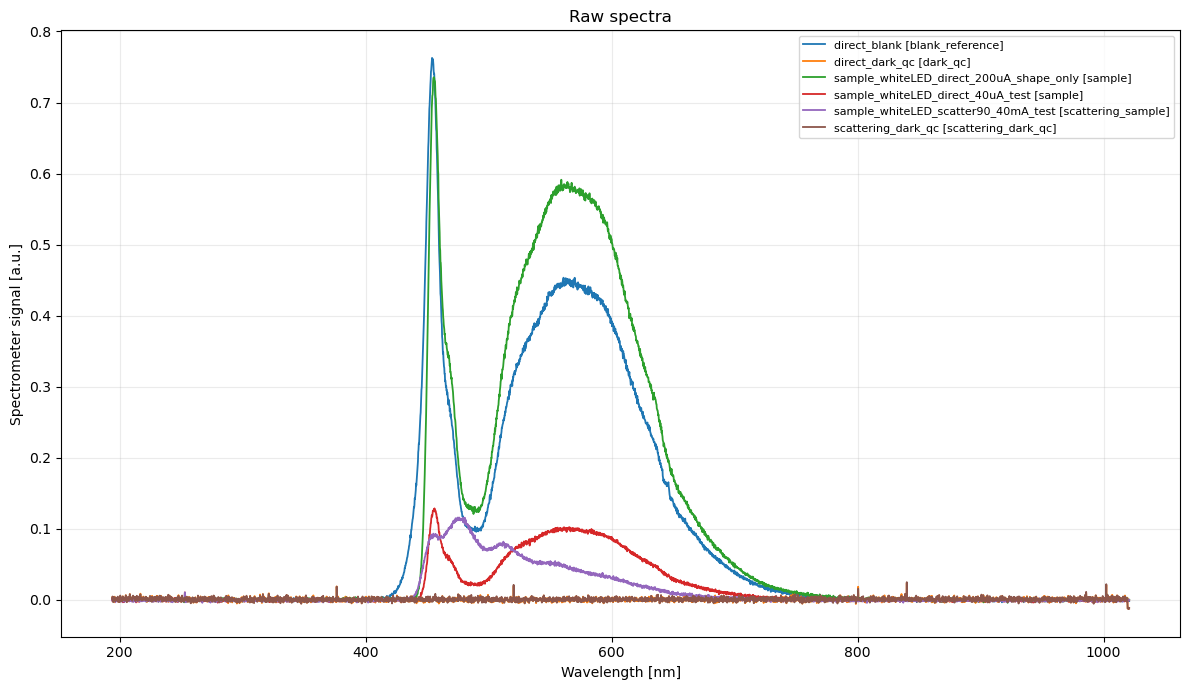

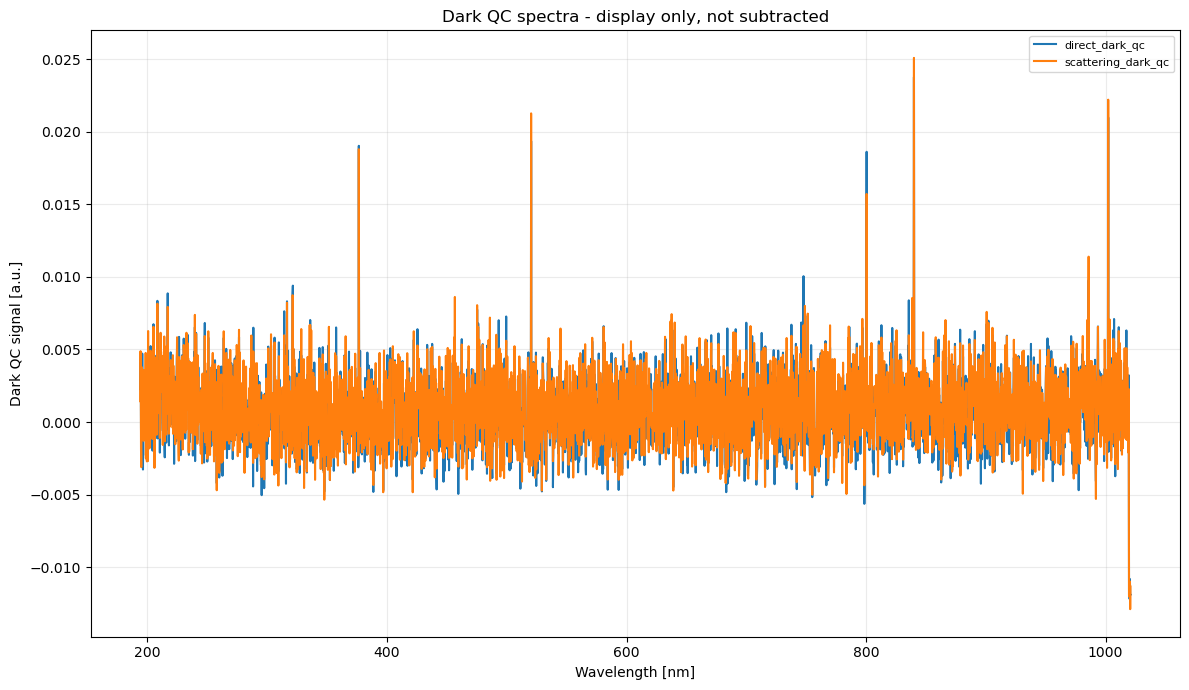

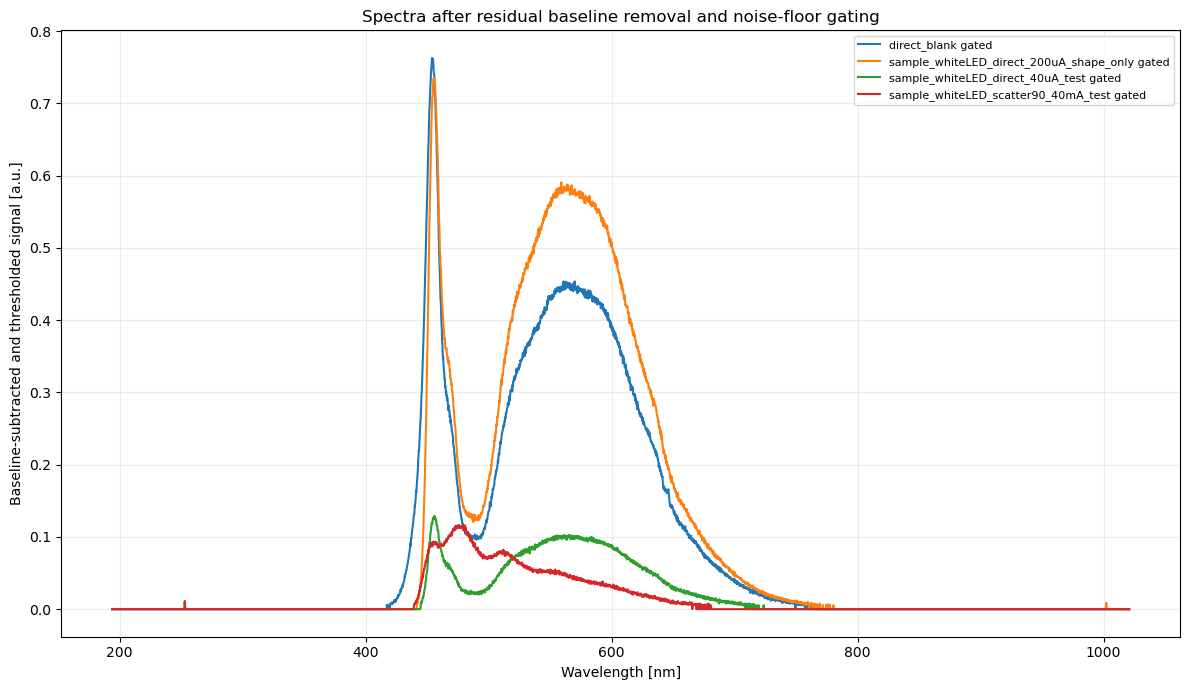

In [6]:
plt.figure(figsize=(12, 7))
for dataset_id, df in raw_spectra.groupby("dataset_id"):
    label = f"{dataset_id} [{df['role'].iloc[0]}]"
    plt.plot(df["wavelength_nm"], df["signal_raw"], label=label, linewidth=1.3)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Spectrometer signal [a.u.]")
plt.title("Raw spectra")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_raw_spectra.png", dpi=170)
plt.show()

# Dark QC only.
dark_qc = raw_spectra[raw_spectra["role"].isin(["dark_qc", "scattering_dark_qc"])]
if not dark_qc.empty:
    plt.figure(figsize=(12, 7))
    for dataset_id, df in dark_qc.groupby("dataset_id"):
        plt.plot(df["wavelength_nm"], df["signal_raw"], label=dataset_id, linewidth=1.5)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Dark QC signal [a.u.]")
    plt.title("Dark QC spectra - display only, not subtracted")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_dark_qc_display_only.png", dpi=170)
    plt.show()
else:
    print("No dark QC files configured. This is fine for a test run, but real campaigns should include dark QC files.")

plt.figure(figsize=(12, 7))
for dataset_id, df in raw_spectra.groupby("dataset_id"):
    if df["role"].iloc[0] in ["dark_qc", "scattering_dark_qc"]:
        continue
    plt.plot(df["wavelength_nm"], df["signal_gated"], label=f"{dataset_id} gated", linewidth=1.5)
plt.xlabel("Wavelength [nm]")
plt.ylabel("Baseline-subtracted and thresholded signal [a.u.]")
plt.title("Spectra after residual baseline removal and noise-floor gating")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_baseline_thresholded_spectra.png", dpi=170)
plt.show()

## 7. Same-current transmittance and absorbance

Direct transmittance is calculated as:

```text
T(λ) = I_sample(λ) / I_blank(λ)
```

In this notebook, `I_sample` and `I_blank` mean **baseline-subtracted and noise-gated** signals, not raw noisy tails.

The blank is air / empty holder. Quartz is not the main blank. Quartz is a control reference used to check whether the setup is stable between campaigns.

The ratio is calculated only where the blank is strong enough. This matters because when the blank signal is close to zero, the ratio `sample / blank` becomes dominated by noise. Those regions are removed by the `valid_ratio_region` mask.

Absorbance is then calculated as:

```text
A(λ) = -log10(T(λ))
```

For irradiated scintillators, the most useful comparisons are usually:

- `T_after_dose / T_before_dose` or a direct comparison of `T(λ)` curves for different doses,
- changes in `A(λ)`,
- integrals of `1 - T`, `A`, or selected spectral bands.

In [7]:
analysis_lo, analysis_hi = CONFIG["analysis_window_nm"]
blank_rows = raw_spectra[(raw_spectra["section"] == "direct") & (raw_spectra["role"] == "blank_reference")]
if blank_rows.empty:
    raise RuntimeError("No direct blank/reference file configured. Absolute direct transmittance cannot be calculated.")

blank_dataset_id = blank_rows["dataset_id"].iloc[0]
blank = blank_rows[blank_rows["dataset_id"] == blank_dataset_id].copy().sort_values("wavelength_nm")
blank_wl = blank["wavelength_nm"].to_numpy()
blank_signal_gated = blank["signal_gated"].to_numpy()
blank_signal_net = blank["signal_net"].to_numpy()
blank_current_value = float(blank["current_value"].iloc[0])
blank_current_unit = str(blank["current_unit"].iloc[0])
blank_geometry = str(blank["geometry"].iloc[0])

blank_peak = float(np.nanmax(blank_signal_gated)) if np.isfinite(np.nanmax(blank_signal_gated)) else 0.0
blank_threshold = CONFIG["blank_min_fraction_of_peak"] * blank_peak
analysis_window_mask = (blank_wl >= analysis_lo) & (blank_wl <= analysis_hi)
valid_blank_region = (blank_signal_gated > 0) & (blank_signal_gated >= blank_threshold)
valid_ratio_region = valid_blank_region & analysis_window_mask

if valid_ratio_region.any():
    print(f"Valid same-current ratio region approximately: {blank_wl[valid_ratio_region][0]:.1f}–{blank_wl[valid_ratio_region][-1]:.1f} nm")
else:
    print("Warning: no valid ratio region found. Check blank signal and thresholds.")

transmittance_records = []
sample_only_records = []

candidate_roles = ["sample", "quartz_reference"]
candidates = raw_spectra[(raw_spectra["section"] == "direct") & (raw_spectra["role"].isin(candidate_roles))]

for dataset_id, df in candidates.groupby("dataset_id"):
    df = df.copy().sort_values("wavelength_nm")
    role = df["role"].iloc[0]
    current_value = float(df["current_value"].iloc[0])
    current_unit = str(df["current_unit"].iloc[0])
    geometry = str(df["geometry"].iloc[0])
    sample_wl = df["wavelength_nm"].to_numpy()
    sample_signal_gated = df["signal_gated"].to_numpy()
    sample_signal_net = df["signal_net"].to_numpy()

    same_current = math.isclose(current_value, blank_current_value) and current_unit == blank_current_unit and geometry == blank_geometry
    same_wavelength_grid = same_grid(sample_wl, blank_wl)

    if same_current and same_wavelength_grid:
        T = safe_ratio(sample_signal_gated, blank_signal_gated, valid_ratio_region)
        T = np.where(T > CONFIG["max_valid_transmittance"], np.nan, T)
        T_smooth = smooth_array(T, CONFIG["smoothing_window_points"], CONFIG["smoothing_polyorder"])
        A = np.where(np.isfinite(T), -np.log10(np.maximum(T, CONFIG["absorbance_floor"])), np.nan)
        A_smooth = smooth_array(A, CONFIG["smoothing_window_points"], CONFIG["smoothing_polyorder"])
        mu = np.where(np.isfinite(T), -np.log(np.maximum(T, CONFIG["absorbance_floor"])) / CONFIG["path_length_mm"], np.nan)
        mu_smooth = smooth_array(mu, CONFIG["smoothing_window_points"], CONFIG["smoothing_polyorder"])

        rec = pd.DataFrame({
            "analysis_type": "same_current_transmittance",
            "comparison_id": f"{dataset_id}_vs_{blank_dataset_id}",
            "dataset_id": dataset_id,
            "sample_id": df["sample_id"].iloc[0],
            "dose_label": df["dose_label"].iloc[0],
            "role": role,
            "reference_dataset_id": blank_dataset_id,
            "current_value": current_value,
            "current_unit": current_unit,
            "geometry": geometry,
            "wavelength_nm": blank_wl,
            "sample_signal_raw": df["signal_raw"].to_numpy(),
            "blank_signal_raw": blank["signal_raw"].to_numpy(),
            "sample_signal_net": sample_signal_net,
            "blank_signal_net": blank_signal_net,
            "sample_signal_gated": sample_signal_gated,
            "blank_signal_gated": blank_signal_gated,
            "sample_above_floor": df["above_signal_floor"].to_numpy(),
            "blank_above_floor": blank["above_signal_floor"].to_numpy(),
            "valid_ratio_region": valid_ratio_region & np.isfinite(T),
            "absolute_signal_difference": blank_signal_gated - sample_signal_gated,
            "fractional_signal_loss": 1.0 - T,
            "transmittance": T,
            "transmittance_smooth": T_smooth,
            "absorbance": A,
            "absorbance_smooth": A_smooth,
            "attenuation_coeff_1_per_mm": mu,
            "attenuation_coeff_1_per_mm_smooth": mu_smooth,
            "trusted_for_integrals": valid_ratio_region & np.isfinite(T),
            "note": "Same-current direct transmittance after residual-baseline subtraction and noise-floor gating."
        })
        transmittance_records.append(rec)
    else:
        denom = np.nanmax(np.abs(sample_signal_gated))
        shape = sample_signal_gated / denom if denom > 0 else np.full_like(sample_signal_gated, np.nan, dtype=float)
        rec = pd.DataFrame({
            "analysis_type": "sample_only_shape_diagnostic",
            "comparison_id": f"{dataset_id}_shape_only",
            "dataset_id": dataset_id,
            "sample_id": df["sample_id"].iloc[0],
            "dose_label": df["dose_label"].iloc[0],
            "role": role,
            "reference_dataset_id": "",
            "current_value": current_value,
            "current_unit": current_unit,
            "geometry": geometry,
            "wavelength_nm": sample_wl,
            "sample_signal_raw": df["signal_raw"].to_numpy(),
            "sample_signal_net": sample_signal_net,
            "sample_signal_gated": sample_signal_gated,
            "sample_shape_norm": shape,
            "sample_shape_norm_smooth": smooth_array(shape, CONFIG["smoothing_window_points"], CONFIG["smoothing_polyorder"]),
            "note": "No matching same-current blank/reference. Shape diagnostic only, not absolute transmittance."
        })
        sample_only_records.append(rec)

transmittance_df = pd.concat(transmittance_records, ignore_index=True) if transmittance_records else pd.DataFrame()
sample_only_df = pd.concat(sample_only_records, ignore_index=True) if sample_only_records else pd.DataFrame()

print("Same-current transmittance records:", len(transmittance_df))
print("Sample-only diagnostic records:", len(sample_only_df))
display(transmittance_df.head())

Valid same-current ratio region approximately: 425.7–734.6 nm
Same-current transmittance records: 3648
Sample-only diagnostic records: 3648


,analysis_type,comparison_id,dataset_id,sample_id,dose_label,role,reference_dataset_id,current_value,current_unit,geometry,wavelength_nm,sample_signal_raw,blank_signal_raw,sample_signal_net,blank_signal_net,sample_signal_gated,blank_signal_gated,sample_above_floor,blank_above_floor,valid_ratio_region,absolute_signal_difference,fractional_signal_loss,transmittance,transmittance_smooth,absorbance,absorbance_smooth,attenuation_coeff_1_per_mm,attenuation_coeff_1_per_mm_smooth,trusted_for_integrals,note
0,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.095093,0.002100,0.001602,0.002299,0.001853,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...
1,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.298660,-0.001707,-0.000403,0.000000,0.000000,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...
2,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.502243,0.000986,0.000677,0.001184,0.000928,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...
3,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.705841,0.000230,-0.000646,0.000429,0.000000,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...
4,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.909454,-0.000456,-0.001522,0.000000,0.000000,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...


## 8. Plot transmittance and absorbance

These plots should no longer show artificial ratio peaks in wavelength regions where the blank/reference is only noise.

The shaded region marks wavelengths where the blank is above the configured threshold and inside the analysis window. Values outside this region are not used for ratio-based integrals.

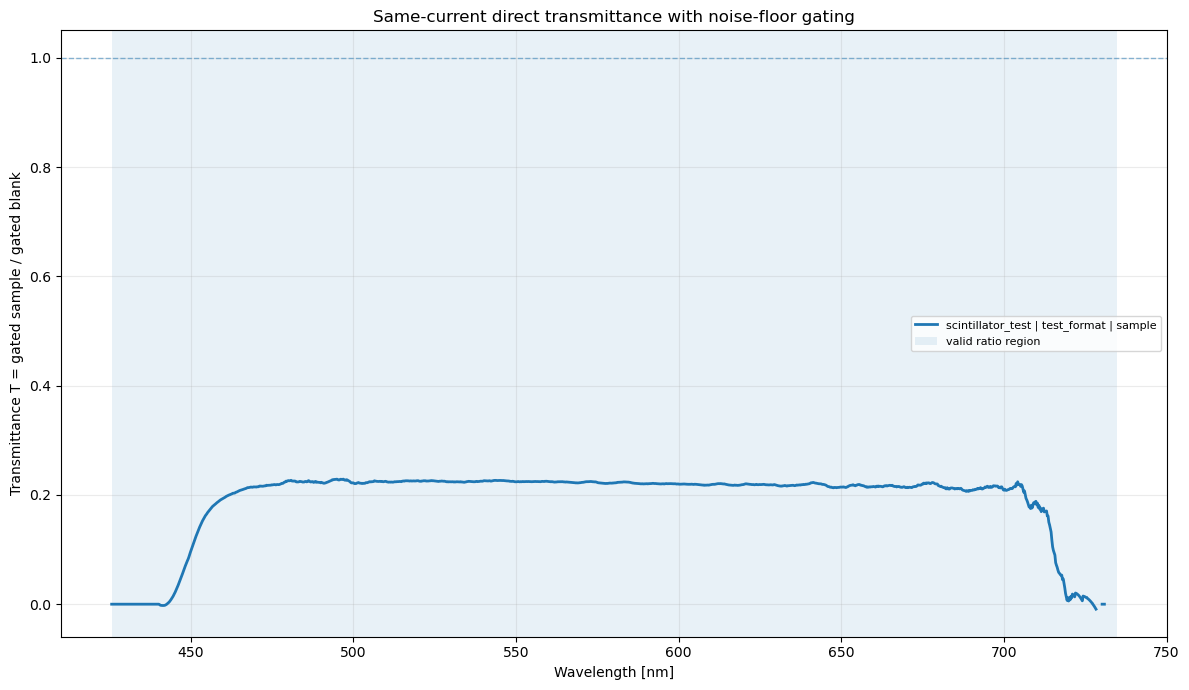

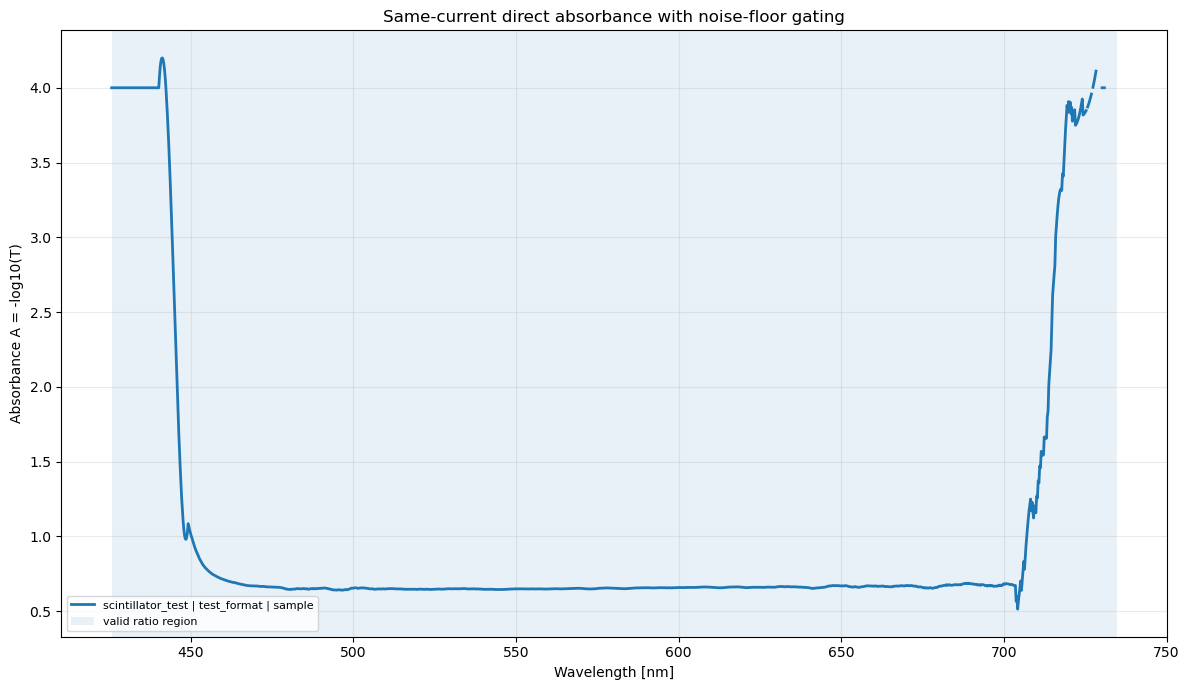

In [8]:
if not transmittance_df.empty:
    plt.figure(figsize=(12, 7))
    for comp_id, df in transmittance_df.groupby("comparison_id"):
        label = f"{df['sample_id'].iloc[0]} | {df['dose_label'].iloc[0]} | {df['role'].iloc[0]}"
        plt.plot(df["wavelength_nm"], df["transmittance_smooth"], label=label, linewidth=2)
    if valid_ratio_region.any():
        plt.axvspan(blank_wl[valid_ratio_region][0], blank_wl[valid_ratio_region][-1], alpha=0.10, label="valid ratio region")
    plt.axhline(1.0, linestyle="--", linewidth=1, alpha=0.5)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Transmittance T = gated sample / gated blank")
    plt.title("Same-current direct transmittance with noise-floor gating")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04_same_current_transmittance_gated.png", dpi=170)
    plt.show()

    plt.figure(figsize=(12, 7))
    for comp_id, df in transmittance_df.groupby("comparison_id"):
        label = f"{df['sample_id'].iloc[0]} | {df['dose_label'].iloc[0]} | {df['role'].iloc[0]}"
        plt.plot(df["wavelength_nm"], df["absorbance_smooth"], label=label, linewidth=2)
    if valid_ratio_region.any():
        plt.axvspan(blank_wl[valid_ratio_region][0], blank_wl[valid_ratio_region][-1], alpha=0.10, label="valid ratio region")
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Absorbance A = -log10(T)")
    plt.title("Same-current direct absorbance with noise-floor gating")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_absorbance_gated.png", dpi=170)
    plt.show()
else:
    print("No same-current transmittance comparisons available.")

## 9. Teaching diagnostic: absolute difference vs fractional attenuation

`blank - sample` is an absolute signal difference. It is often largest near the LED/spectrometer peak, because both signals are large there.

`1 - T` is a fractional loss. It answers a different question: what fraction of the incident signal was removed by the sample?

Absorbance is based on this fractional ratio, not on the absolute raw difference. Therefore, the absorbance plot does not need to peak exactly where the raw blank-sample difference is largest.

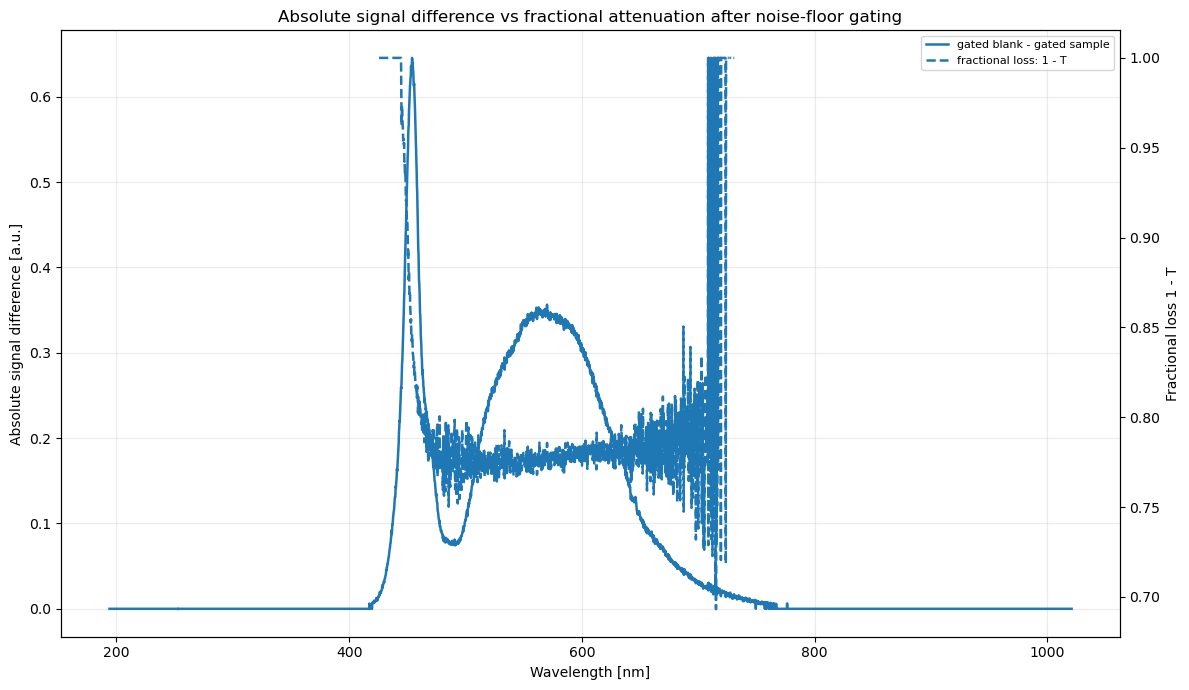

In [9]:
if not transmittance_df.empty:
    first_comp = transmittance_df[transmittance_df["role"] == "sample"]
    if first_comp.empty:
        first_comp = transmittance_df
    df = first_comp.groupby("comparison_id").get_group(first_comp["comparison_id"].iloc[0])

    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax1.plot(df["wavelength_nm"], df["absolute_signal_difference"], label="gated blank - gated sample", linewidth=1.8)
    ax1.set_xlabel("Wavelength [nm]")
    ax1.set_ylabel("Absolute signal difference [a.u.]")
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(df["wavelength_nm"], df["fractional_signal_loss"], label="fractional loss: 1 - T", linestyle="--", linewidth=1.8)
    ax2.set_ylabel("Fractional loss 1 - T")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=8)
    plt.title("Absolute signal difference vs fractional attenuation after noise-floor gating")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "06_difference_vs_fractional_loss_gated.png", dpi=170)
    plt.show()
else:
    print("No transmittance data available for this diagnostic plot.")

## 10. Sample-only diagnostic spectra

A direct sample measured at a different diode current than the blank is not used for absolute transmittance.

However, after baseline/noise gating it can still be useful for shape diagnostics: peak position, spectral broadening, or qualitative changes in the measured spectrum. This is especially useful when a higher diode current was chosen only to bring the transmitted sample signal into a convenient dynamic range.

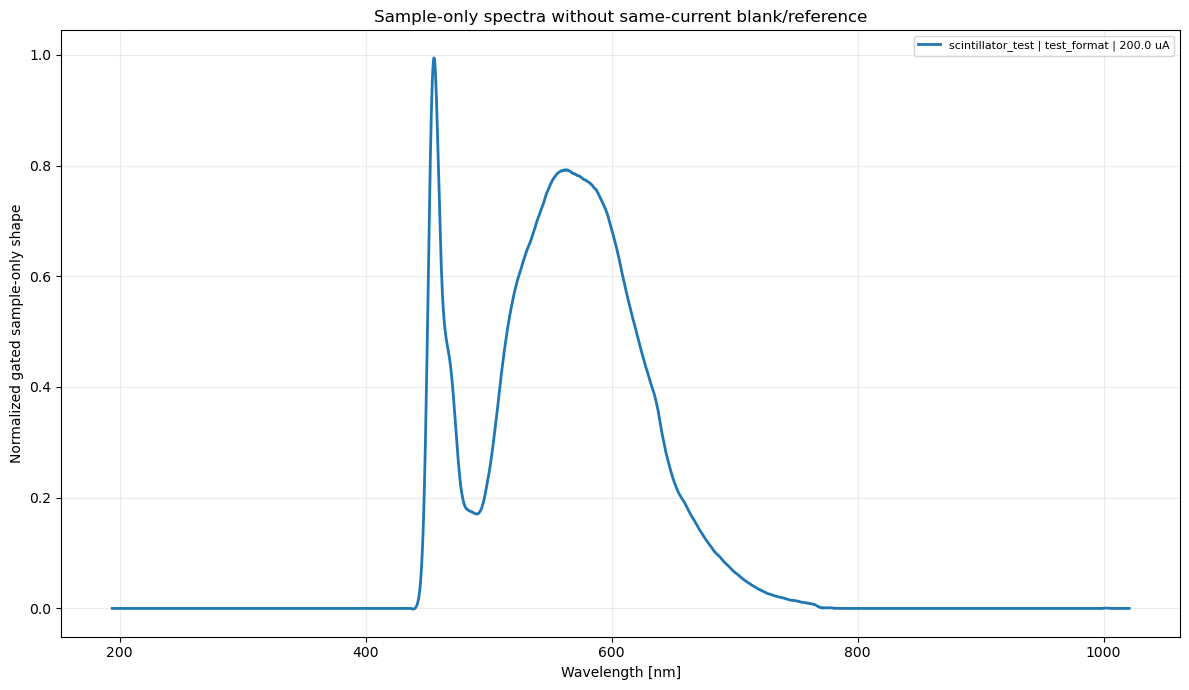

In [10]:
if not sample_only_df.empty:
    plt.figure(figsize=(12, 7))
    for dataset_id, df in sample_only_df.groupby("dataset_id"):
        label = f"{df['sample_id'].iloc[0]} | {df['dose_label'].iloc[0]} | {df['current_value'].iloc[0]} {df['current_unit'].iloc[0]}"
        plt.plot(df["wavelength_nm"], df["sample_shape_norm_smooth"], label=label, linewidth=2)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Normalized gated sample-only shape")
    plt.title("Sample-only spectra without same-current blank/reference")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "07_sample_only_shape_diagnostic_gated.png", dpi=170)
    plt.show()
else:
    print("No sample-only diagnostic spectra available.")

## 11. Quartz reference stability check

Quartz/fused silica is a stability/control sample, not the main blank.

If quartz is measured in direct transmission, the notebook calculates quartz transmittance relative to the same-current blank. In repeated campaigns, this curve should remain stable. If it changes significantly, the optical setup, alignment, detector response, holder, or acquisition settings may have changed.

In [11]:
quartz_direct = transmittance_df[transmittance_df["role"] == "quartz_reference"] if not transmittance_df.empty else pd.DataFrame()
if not quartz_direct.empty:
    plt.figure(figsize=(12, 7))
    for comp_id, df in quartz_direct.groupby("comparison_id"):
        plt.plot(df["wavelength_nm"], df["transmittance_smooth"], label=comp_id, linewidth=2)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Quartz transmittance relative to blank")
    plt.title("Quartz direct-transmission stability check")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "08_quartz_direct_stability_check.png", dpi=170)
    plt.show()
else:
    print("No direct quartz reference file configured.")

No direct quartz reference file configured.


## 12. Scattering analysis

Scattering measurements are separate from direct transmittance.

For 90° scattering, if a scattering blank is provided, the notebook subtracts the baseline/noise-gated scattering blank from the baseline/noise-gated sample signal:

```text
S_net(λ) = S_sample_gated(λ) - S_blank_gated(λ)
```

Negative values after blank subtraction are clipped to zero for shape diagnostics and integrals.

Quartz scattering is a stability/control measurement. It helps detect setup drift or unexpected background changes.

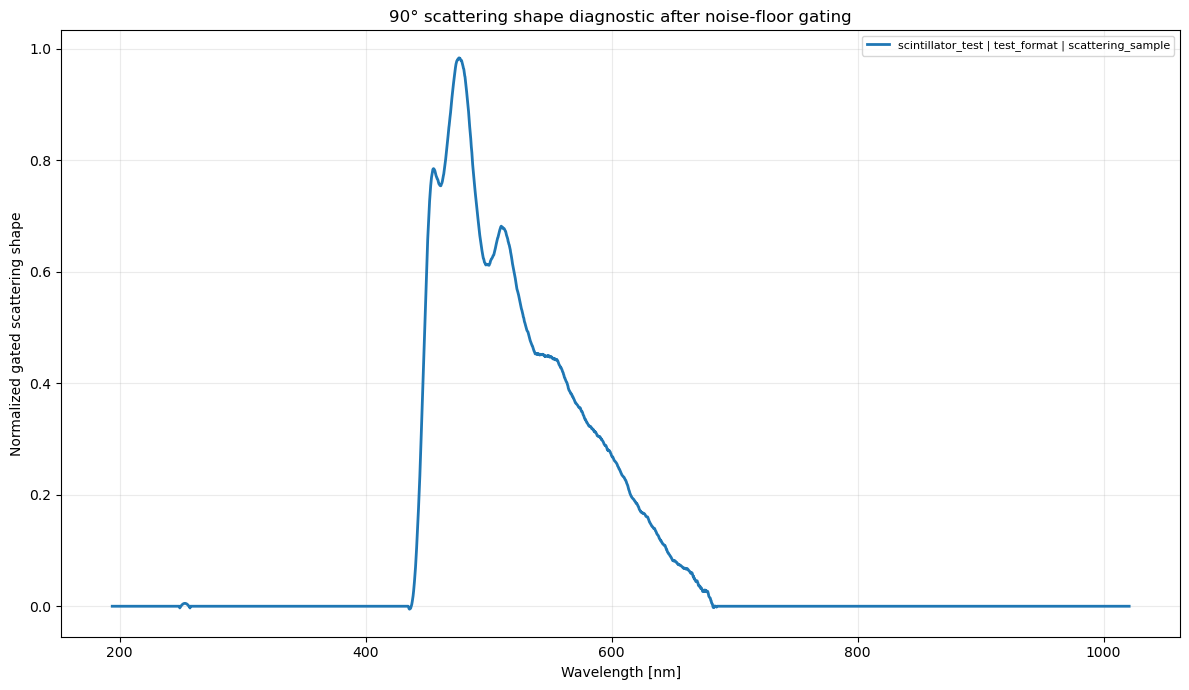

In [12]:
scattering_df_records = []
scatter_section = raw_spectra[raw_spectra["section"] == "scattering"]
scatter_blank_rows = scatter_section[scatter_section["role"] == "scattering_blank"]
scatter_blank = None
if not scatter_blank_rows.empty:
    scatter_blank_id = scatter_blank_rows["dataset_id"].iloc[0]
    scatter_blank = scatter_blank_rows[scatter_blank_rows["dataset_id"] == scatter_blank_id].copy().sort_values("wavelength_nm")

for role in ["scattering_sample", "scattering_quartz"]:
    candidates = scatter_section[scatter_section["role"] == role]
    for dataset_id, df in candidates.groupby("dataset_id"):
        df = df.copy().sort_values("wavelength_nm")
        wl = df["wavelength_nm"].to_numpy()
        y = df["signal_gated"].to_numpy()

        if scatter_blank is not None and same_grid(wl, scatter_blank["wavelength_nm"].to_numpy()):
            blank_y = scatter_blank["signal_gated"].to_numpy()
            y_net = y - blank_y
            reference_id = scatter_blank["dataset_id"].iloc[0]
            note = "Scattering blank was subtracted after baseline/noise gating."
        else:
            blank_y = np.full_like(y, np.nan, dtype=float)
            y_net = y
            reference_id = ""
            note = "No scattering blank available. Spectrum is baseline/noise gated only."

        y_net = np.where(y_net > 0, y_net, 0.0)
        denom = np.nanmax(np.abs(y_net))
        shape = y_net / denom if denom > 0 else np.full_like(y_net, np.nan, dtype=float)
        shape_smooth = smooth_array(shape, CONFIG["smoothing_window_points"], CONFIG["smoothing_polyorder"])

        rec = pd.DataFrame({
            "analysis_type": "scattering_shape_diagnostic",
            "comparison_id": f"{dataset_id}_scattering_shape",
            "dataset_id": dataset_id,
            "sample_id": df["sample_id"].iloc[0],
            "dose_label": df["dose_label"].iloc[0],
            "role": role,
            "reference_dataset_id": reference_id,
            "current_value": df["current_value"].iloc[0],
            "current_unit": df["current_unit"].iloc[0],
            "geometry": df["geometry"].iloc[0],
            "wavelength_nm": wl,
            "scattering_signal_raw": df["signal_raw"].to_numpy(),
            "scattering_signal_gated": y,
            "scattering_blank_signal_gated": blank_y,
            "scattering_signal_net": y_net,
            "scattering_shape_norm": shape,
            "scattering_shape_norm_smooth": shape_smooth,
            "trusted_for_integrals": (wl >= analysis_lo) & (wl <= analysis_hi) & np.isfinite(shape),
            "note": note,
        })
        scattering_df_records.append(rec)

scattering_df = pd.concat(scattering_df_records, ignore_index=True) if scattering_df_records else pd.DataFrame()

if not scattering_df.empty:
    plt.figure(figsize=(12, 7))
    for comp_id, df in scattering_df.groupby("comparison_id"):
        label = f"{df['sample_id'].iloc[0]} | {df['dose_label'].iloc[0]} | {df['role'].iloc[0]}"
        plt.plot(df["wavelength_nm"], df["scattering_shape_norm_smooth"], label=label, linewidth=2)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Normalized gated scattering shape")
    plt.title("90° scattering shape diagnostic after noise-floor gating")
    plt.grid(alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "09_scattering_shape_gated.png", dpi=170)
    plt.show()
else:
    print("No scattering sample/quartz files configured.")

## 13. Integrals under curves

Integrals are calculated after baseline/noise gating. This is important because otherwise large wavelength intervals containing only noise could dominate AUC-based comparisons.

Useful quantities:

- `gated_signal_auc` — area under each baseline/noise-gated spectrum.
- `transmittance_auc` — area under valid `T(λ)`.
- `fractional_loss_auc` — area under `1 - T(λ)`.
- `absorbance_auc` — area under `A(λ)`.
- `scattering_net_auc` — area under net 90° scattering signal.
- `scattering_shape_auc` — area under normalized scattering shape.

For dose studies, compare these values between dose labels for the same sample and same measurement configuration.

,dataset_id,analysis_type,quantity,value,unit,range_nm,note,comparison_id,sample_id,dose_label
0,direct_blank,raw_gated_spectrum,gated_signal_auc,73.504721,signal*nm,400.0-750.0,Residual baseline subtracted; values below noi...,NaN,NaN,NaN
1,direct_dark_qc,raw_gated_spectrum,gated_signal_auc,NaN,signal*nm,400.0-750.0,Residual baseline subtracted; values below noi...,NaN,NaN,NaN
2,sample_whiteLED_direct_200uA_shape_only,raw_gated_spectrum,gated_signal_auc,87.723829,signal*nm,400.0-750.0,Residual baseline subtracted; values below noi...,NaN,NaN,NaN
3,sample_whiteLED_direct_40uA_test,raw_gated_spectrum,gated_signal_auc,15.008339,signal*nm,400.0-750.0,Residual baseline subtracted; values below noi...,NaN,NaN,NaN
4,sample_whiteLED_scatter90_40mA_test,raw_gated_spectrum,gated_signal_auc,11.578008,signal*nm,400.0-750.0,Residual baseline subtracted; values below noi...,NaN,NaN,NaN
5,scattering_dark_qc,raw_gated_spectrum,gated_signal_auc,NaN,signal*nm,400.0-750.0,Residual baseline subtracted; values below noi...,NaN,NaN,NaN
6,sample_whiteLED_direct_40uA_test,same_current_transmittance,transmittance_auc,57.851655,T*nm,valid ratio region inside analysis window,Same-current comparison after baseline/noise g...,sample_whiteLED_direct_40uA_test_vs_direct_blank,scintillator_test,test_format
7,sample_whiteLED_direct_40uA_test,same_current_transmittance,fractional_loss_auc,251.067535,(1-T)*nm,valid ratio region inside analysis window,Same-current comparison after baseline/noise g...,sample_whiteLED_direct_40uA_test_vs_direct_blank,scintillator_test,test_format
8,sample_whiteLED_direct_40uA_test,same_current_transmittance,absorbance_auc,340.006534,A*nm,valid ratio region inside analysis window,Same-current comparison after baseline/noise g...,sample_whiteLED_direct_40uA_test_vs_direct_blank,scintillator_test,test_format
9,sample_whiteLED_direct_40uA_test,same_current_transmittance,absolute_signal_difference_auc,58.333141,signal*nm,valid ratio region inside analysis window,Same-current comparison after baseline/noise g...,sample_whiteLED_direct_40uA_test_vs_direct_blank,scintillator_test,test_format


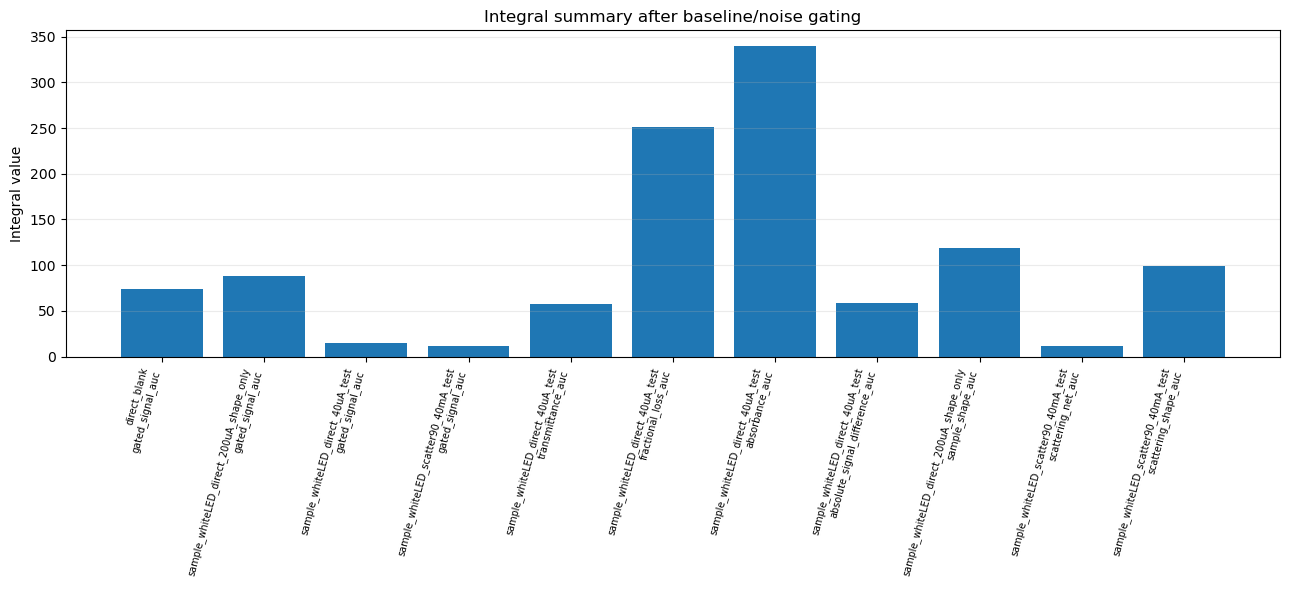

In [13]:
integral_rows = []

for dataset_id, df in raw_spectra.groupby("dataset_id"):
    wl = df["wavelength_nm"].to_numpy()
    mask = (wl >= analysis_lo) & (wl <= analysis_hi) & (df["signal_gated"].to_numpy() > 0)
    integral_rows.append({
        "dataset_id": dataset_id,
        "analysis_type": "raw_gated_spectrum",
        "quantity": "gated_signal_auc",
        "value": integrate_quantity(wl, df["signal_gated"].to_numpy(), mask),
        "unit": "signal*nm",
        "range_nm": f"{analysis_lo}-{analysis_hi}",
        "note": "Residual baseline subtracted; values below noise floor set to zero."
    })

if not transmittance_df.empty:
    for comp_id, df in transmittance_df.groupby("comparison_id"):
        wl = df["wavelength_nm"].to_numpy()
        mask = df["trusted_for_integrals"].to_numpy(dtype=bool)
        for quantity, column, unit in [
            ("transmittance_auc", "transmittance", "T*nm"),
            ("fractional_loss_auc", "fractional_signal_loss", "(1-T)*nm"),
            ("absorbance_auc", "absorbance", "A*nm"),
            ("absolute_signal_difference_auc", "absolute_signal_difference", "signal*nm"),
        ]:
            integral_rows.append({
                "dataset_id": df["dataset_id"].iloc[0],
                "comparison_id": comp_id,
                "sample_id": df["sample_id"].iloc[0],
                "dose_label": df["dose_label"].iloc[0],
                "analysis_type": "same_current_transmittance",
                "quantity": quantity,
                "value": integrate_quantity(wl, df[column].to_numpy(), mask),
                "unit": unit,
                "range_nm": "valid ratio region inside analysis window",
                "note": "Same-current comparison after baseline/noise gating."
            })

if not sample_only_df.empty:
    for dataset_id, df in sample_only_df.groupby("dataset_id"):
        wl = df["wavelength_nm"].to_numpy()
        mask = (wl >= analysis_lo) & (wl <= analysis_hi) & np.isfinite(df["sample_shape_norm"].to_numpy())
        integral_rows.append({
            "dataset_id": dataset_id,
            "sample_id": df["sample_id"].iloc[0],
            "dose_label": df["dose_label"].iloc[0],
            "analysis_type": "sample_only_shape_diagnostic",
            "quantity": "sample_shape_auc",
            "value": integrate_quantity(wl, df["sample_shape_norm"].to_numpy(), mask),
            "unit": "normalized*nm",
            "range_nm": f"{analysis_lo}-{analysis_hi}",
            "note": "Shape diagnostic only, not absolute transmittance."
        })

if not scattering_df.empty:
    for comp_id, df in scattering_df.groupby("comparison_id"):
        wl = df["wavelength_nm"].to_numpy()
        mask = df["trusted_for_integrals"].to_numpy(dtype=bool)
        for quantity, column, unit in [
            ("scattering_net_auc", "scattering_signal_net", "signal*nm"),
            ("scattering_shape_auc", "scattering_shape_norm", "normalized*nm"),
        ]:
            integral_rows.append({
                "dataset_id": df["dataset_id"].iloc[0],
                "comparison_id": comp_id,
                "sample_id": df["sample_id"].iloc[0],
                "dose_label": df["dose_label"].iloc[0],
                "analysis_type": "scattering_shape_diagnostic",
                "quantity": quantity,
                "value": integrate_quantity(wl, df[column].to_numpy(), mask),
                "unit": unit,
                "range_nm": f"{analysis_lo}-{analysis_hi}",
                "note": df["note"].iloc[0]
            })

integral_summary = pd.DataFrame(integral_rows)
integral_summary.to_csv(TABLE_DIR / "integral_summary.csv", index=False)
display(integral_summary)

if not integral_summary.empty:
    plot_df = integral_summary.dropna(subset=["value"]).copy()
    plot_df["label"] = plot_df["dataset_id"].astype(str) + "\n" + plot_df["quantity"].astype(str)
    plt.figure(figsize=(13, 6))
    plt.bar(np.arange(len(plot_df)), plot_df["value"])
    plt.xticks(np.arange(len(plot_df)), plot_df["label"], rotation=75, ha="right", fontsize=7)
    plt.ylabel("Integral value")
    plt.title("Integral summary after baseline/noise gating")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "10_integral_summary_gated.png", dpi=170)
    plt.show()

## 14. Export analysis-ready dataframe

The main output is:

```text
results/processed/analysis_ready_dataframe.csv
```

This file can be loaded by a separate final-analysis notebook. It contains all processed curves, masks, thresholds and metadata needed for final dose-dependent comparisons.

In [14]:
frames = []
if not transmittance_df.empty:
    frames.append(transmittance_df)
if not sample_only_df.empty:
    frames.append(sample_only_df)
if not scattering_df.empty:
    frames.append(scattering_df)

analysis_ready = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()
analysis_ready.to_csv(PROCESSED_DIR / "analysis_ready_dataframe.csv", index=False)

print("Saved:")
print(PROCESSED_DIR / "analysis_ready_dataframe.csv")
print(PROCESSED_DIR / "raw_spectra_long.csv")
print(TABLE_DIR / "integral_summary.csv")
print(TABLE_DIR / "qc_summary.csv")
print(FIG_DIR)

display(analysis_ready.head())

Saved:
../example_data/raw/analysis_outputs/processed/analysis_ready_dataframe.csv
../example_data/raw/analysis_outputs/processed/raw_spectra_long.csv
../example_data/raw/analysis_outputs/tables/integral_summary.csv
../example_data/raw/analysis_outputs/tables/qc_summary.csv
../example_data/raw/analysis_outputs/figures


,analysis_type,comparison_id,dataset_id,sample_id,dose_label,role,reference_dataset_id,current_value,current_unit,geometry,wavelength_nm,sample_signal_raw,blank_signal_raw,sample_signal_net,blank_signal_net,sample_signal_gated,blank_signal_gated,sample_above_floor,blank_above_floor,valid_ratio_region,absolute_signal_difference,fractional_signal_loss,transmittance,transmittance_smooth,absorbance,absorbance_smooth,attenuation_coeff_1_per_mm,attenuation_coeff_1_per_mm_smooth,trusted_for_integrals,note,sample_shape_norm,sample_shape_norm_smooth,scattering_signal_raw,scattering_signal_gated,scattering_blank_signal_gated,scattering_signal_net,scattering_shape_norm,scattering_shape_norm_smooth
0,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.095093,0.002100,0.001602,0.002299,0.001853,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.298660,-0.001707,-0.000403,0.000000,0.000000,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.502243,0.000986,0.000677,0.001184,0.000928,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.705841,0.000230,-0.000646,0.000429,0.000000,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,same_current_transmittance,sample_whiteLED_direct_40uA_test_vs_direct_blank,sample_whiteLED_direct_40uA_test,scintillator_test,test_format,sample,direct_blank,40.0,uA,direct,194.909454,-0.000456,-0.001522,0.000000,0.000000,0.0,0.0,False,False,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Same-current direct transmittance after residu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 15. Run report

This cell writes a short technical report. It is meant as a run log, not as a polished scientific report.

In [15]:
report_lines = []
report_lines.append("# Spectrophotometer pipeline v5 run report")
report_lines.append("")
report_lines.append("This report was generated automatically from the single Colab/Jupyter pipeline.")
report_lines.append("")
report_lines.append("The example files included with the notebook are test-format files only and should not be interpreted as physical measurement results.")
report_lines.append("")
report_lines.append("## Main assumptions")
report_lines.append("")
report_lines.append("- Spectrometer exports are assumed to be already dark-corrected.")
report_lines.append("- Dark files are displayed only as QC spectra and are not subtracted.")
report_lines.append("- Direct transmittance is calculated only for the same diode current, same current unit, same geometry and same wavelength grid.")
report_lines.append("- Residual baseline subtraction and noise-floor gating are applied before ratios and integrals.")
report_lines.append("- Air / empty holder is the direct blank. Quartz is a setup-stability control sample.")
report_lines.append("")
report_lines.append("## Noise gating settings")
report_lines.append("")
for k in ["analysis_window_nm", "baseline_ranges_nm", "blank_min_fraction_of_peak", "signal_floor_fraction_of_peak", "noise_sigma_multiplier", "max_valid_transmittance"]:
    report_lines.append(f"- `{k}`: {CONFIG[k]}")
report_lines.append("")
report_lines.append("## Outputs")
report_lines.append("")
report_lines.append("- `analysis_ready_dataframe.csv`")
report_lines.append("- `raw_spectra_long.csv`")
report_lines.append("- `integral_summary.csv`")
report_lines.append("- `qc_summary.csv`")
report_lines.append("- figures in the `figures/` directory")

report_path = REPORT_DIR / "run_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print(report_path)

../example_data/raw/analysis_outputs/report/run_report.md
